# Notebook 07 — Burning Risk Map

**Purpose:** Produce two publication-quality choropleth maps — one showing the continuous BRS gradient and one showing the four discrete risk classes — and save both to `outputs/maps/`.

**Input:** `data/processed/Punjab_Haryana_districts.gpkg`, `data/processed/burning_risk_scores.csv`  
**Output:** `data/processed/burning_risk_map.png`, `outputs/maps/01_brs_continuous.png`, `outputs/maps/01_brs_classified.png`

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('outputs/maps', exist_ok=True)

# Load spatial and score data 
gdf  = gpd.read_file('../Data/Processed/Punjab_Haryana_districts.gpkg')
risk = pd.read_csv('../Data/Processed/burning_risk_scores.csv')

print(f"Districts in GDF : {len(gdf)}")
print(f"Districts in risk: {len(risk)}")


Districts in GDF : 43
Districts in risk: 43


In [2]:
# Standardise district names and merge 
gdf['district']  = gdf['NAME_2'].str.strip().str.title()
risk['district'] = risk['district'].str.strip().str.title()

map_df = gdf.merge(risk, on='district', how='left')

# Fill any unmatched districts with 0 / 'Low' so the map renders cleanly
map_df['BRS']        = map_df['BRS'].fillna(0)
map_df['risk_class'] = map_df['risk_class'].fillna('Low')

unmatched = map_df[map_df['BRS'] == 0]['district'].tolist()
if unmatched:
    print(f"Districts with no BRS score (set to 0): {unmatched}")
else:
    print("All districts matched successfully")


✅ All districts matched successfully


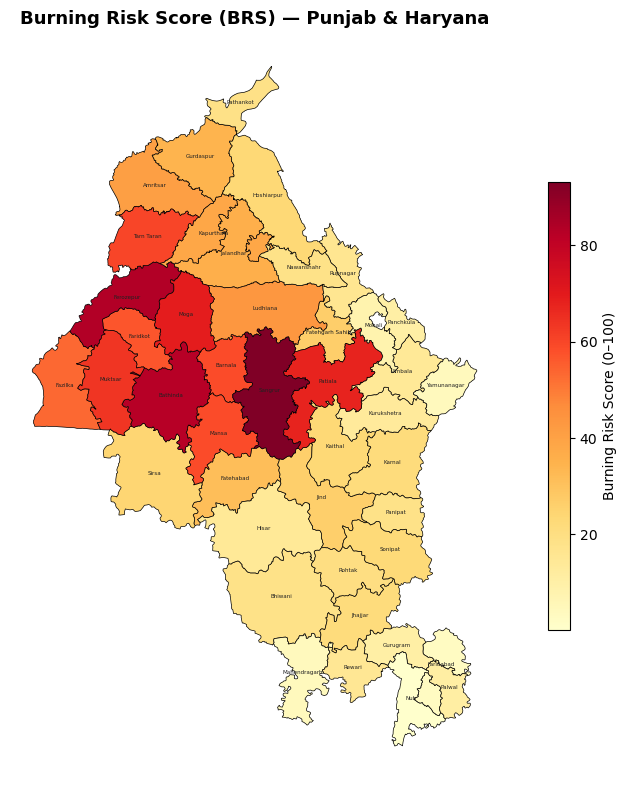

✅ Saved: outputs/maps/01_brs_continuous.png


In [3]:
# Map 1: Continuous BRS choropleth 
fig, ax = plt.subplots(figsize=(10, 8))

map_df.plot(
    column     = 'BRS',
    cmap       = 'YlOrRd',
    linewidth  = 0.5,
    edgecolor  = 'black',
    legend     = True,
    legend_kwds= {'label': 'Burning Risk Score (0–100)', 'shrink': 0.6},
    ax         = ax,
)

# Label each district
for _, row in map_df.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row['district'], xy=(c.x, c.y),
        fontsize=4, ha='center', color='#222222'
    )

ax.set_title('Burning Risk Score (BRS) — Punjab & Haryana', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('../Outputs/Maps/01_brs_continuous.png', dpi=200, bbox_inches='tight')
plt.savefig('../Data/Processed/burning_risk_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: outputs/maps/01_brs_continuous.png")

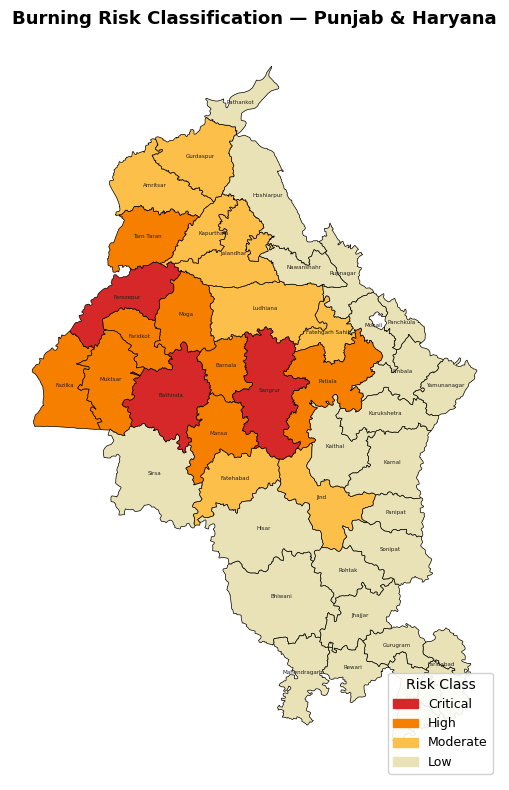

✅ Saved: outputs/maps/01_brs_classified.png


In [4]:
# Map 2: Categorical risk classification 
risk_palette = {
    'Critical': '#d62828',
    'High'    : '#f77f00',
    'Moderate': '#fcbf49',
    'Low'     : '#eae2b7',
}
map_df['color'] = map_df['risk_class'].map(risk_palette)

fig, ax = plt.subplots(figsize=(10, 8))
map_df.plot(color=map_df['color'], edgecolor='black', linewidth=0.5, ax=ax)

# Label each district
for _, row in map_df.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row['district'], xy=(c.x, c.y),
        fontsize=4, ha='center', color='#222222'
    )

# Manual legend
patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in risk_palette.items()
]
ax.legend(handles=patches, title='Risk Class', loc='lower right', fontsize=9, framealpha=0.9)
ax.set_title('Burning Risk Classification — Punjab & Haryana', fontsize=13, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('../Outputs/Maps/01_brs_classified.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: outputs/maps/01_brs_classified.png")